# Who Walked Together, and What Else Did They Share?

A walkthrough of **crategraph** using the Wallaby Club Compendium (WALL) — an RO-Crate recording over a century of Australia's oldest walking club.

This notebook follows the investigative threads of a social historian exploring how voluntary associations shaped community bonds in late-nineteenth and early-twentieth century Melbourne. The Wallaby Club, founded in 1894, brought together barristers, headmasters, surgeons, journalists, public servants, and scientists — all united by a Saturday walk.

We'll use crategraph's API to explore:
1. **Membership & professions** — who were these walkers?
2. **Leadership patterns** — who held office, and did certain professions dominate?
3. **Family connections** — fathers, sons, and siblings across generations
4. **Temporal overlaps** — who actually walked alongside whom?
5. **The walks themselves** — over 100 years of routes through the Victorian bush

Based on the user story: [`wall-club-membership-ties.md`](../stories/wall-club-membership-ties.md)

## Loading the Crate

In [1]:
from crategraph import Crate

wall = Crate("../../../data/ohrm/WALL/")
wall

Graph(2029 entities, 3574 relationships, source='../../../data/ohrm/WALL')

## First Impressions

Before diving into specific questions, let's orient ourselves with a summary of what the crate contains.

In [2]:
wall.summary()

=== Graph Summary ===
Source: ../../../data/ohrm/WALL
Entities: 2029 | Relationships: 3574

Entity types:
  Related             558  ▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒
  Person              505  ▒▒▒▒▒▒▒▒▒▒▒▒▒▒
  Person, Membership  504  ▒▒▒▒▒▒▒▒▒▒▒▒▒▒
  Function            126  ▒▒▒
  Walks               116  ▒▒▒
  +25 more

Relationship types:
  preparedBy     663  ▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒
  relatedEvents  616  ▒▒▒▒▒▒▒▒▒▒▒▒▒▒
  entity         616  ▒▒▒▒▒▒▒▒▒▒▒▒▒▒
  sourceOf       585  ▒▒▒▒▒▒▒▒▒▒▒▒▒
  targetOf       585  ▒▒▒▒▒▒▒▒▒▒▒▒▒
  +9 more

Most connected: Gavan McCarthy (663), President (227), Honorary Secretary (49)

In [3]:
print("Entity types:", sorted(wall.types))
print()
print("Relationship types:", sorted(wall.relationship_types))

Entity types: ['Annual General Meeting and Dinner', 'Book', 'Child', 'Christmas Dinner', 'CreativeWork', 'Cultural_Artefact', 'DigitalObject', 'DigitalObjectVersion', 'EditedBook', 'File', 'Function', 'Graphic', 'Historic note', 'Image', 'Membership', 'Official_Position', 'Organisation', 'Outing', 'Parent', 'Person', 'Place', 'Previous', 'Primary', 'PublishedResource', 'Related', 'RepositoryObject', 'ResourceSection', 'Sibling', 'State', 'Subordinate', 'Subsequent', 'Superior', 'Thumbnail', 'Walk', 'Walks']

Relationship types: ['Relationship', 'birthPlace', 'birthState', 'deathPlace', 'deathState', 'dobject', 'entity', 'hasFile', 'location', 'place', 'preparedBy', 'relatedEvents', 'sourceOf', 'targetOf']


A type-level snapshot shows how these entity types relate to each other at a glance:

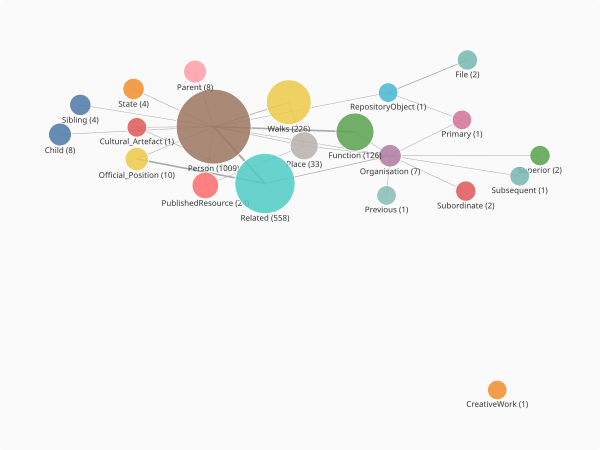

In [4]:
wall.glimpse()

---
## Thread 1 — Membership & Professions

_"Can I see the full membership of this club, and what these men actually did for a living?"_

The crate records each member as a Person, with their professional roles stored as separate Function entries — educationist, engineer, judge, and so on.

In [5]:
# Select all Person entities (includes Membership sub-type)
persons = wall.select(entity_types=["Person"])
print(f"{len(persons)} Person entities in the crate")

# Filter to 'pure' Person entities (not Membership events) that have a function
members_with_function = [
    e for e in persons.entities if "Membership" not in e.types and e.properties.get("function")
]
print(f"{len(members_with_function)} members with a recorded profession")

# Show a sample
print("\nSample members and their professions:")
for member in members_with_function[:15]:
    print(f"  {member.name} — {member.properties['function']}")

1009 Person entities in the crate
285 members with a recorded profession

Sample members and their professions:
  Hughes, William Morris — politician
  Derham, F.T. — business man, company director, politician, public servant
  Stockman, Peter — Baptist minister
  Race, P. — dentist
  Moore, Harold — urologist
  Krome, Otto George Hermann Dittmar — educationist
  Simpson, R. McC. — architect
  Doery, Edward Keith — accountant
  Ashton, Douglas H. — academic, plant ecologist
  Zwar, Bernard T. — surgeon
  Buesst, Tristan N.M. — barrister
  McCutcheon, A. Douglas — physician
  Russell, Hamish M. — agricultural scientist
  Wunderlich, Jeff A. — science administrator, X-ray crystallographer
  Chapman, James G. — microbiologist


The range is striking — educationists, engineers, judges, librarians, poets, surgeons. These were people shaping Melbourne's institutions.

Let's see what professions are recorded and which were most common:

In [6]:
# All recorded professional functions
functions = wall.select(entity_types=["Function"])
print(f"{len(functions)} distinct professional functions recorded\n")

# Which professions had the most members? Count via the Person->Function subgraph.
person_function = wall.query("(a:Person)-[:Relationship]->(b:Function)")
top_functions = person_function.most_connected(n=15, entity_types=["Function"])
print("Most common professions (by linked members):")
for func, degree in top_functions:
    print(f"  {func.name}: {degree}")

126 distinct professional functions recorded



Most common professions (by linked members):
  academic: 28
  engineer: 23
  public servant: 21
  politician: 15
  educationist: 15
  chemist: 13
  barrister: 13
  medical practitioner: 12
  judge: 12
  accountant: 11
  lawyer: 11
  physician: 10
  scientist: 10
  author: 9
  agricultural scientist: 9


In [7]:
# Query the Person → Function relationship network using Cypher
person_function = wall.query("(a:Person)-[:Relationship]->(b:Function)")
print(f"Person-Function subgraph: {len(person_function)} entities")
person_function.visualise(renderer="2d", colour_by="type", collapse_edges=True)

Person-Function subgraph: 410 entities


<class 'pyvis.network.Network'> |N|=410 |E|=453

---
## Thread 2 — Leadership Patterns

_"I wonder if the pattern of who became president reveals which professions carried weight in the Club over time."_

The crate records official positions (President, Honorary Secretary, etc.) and links them to the people who held those roles, often with the years they served.

In [8]:
# What official positions exist?
positions = wall.select(entity_types=["Official_Position"])
print("Official positions:")
for pos in positions.entities:
    print(f"  {pos.name}")

Official positions:
  Public Officer
  President
  Honorary Life Members
  Vice-President
  Honorary Treasurer
  Emeritus Members
  Auditor
  Honorary Secretary
  Walks Secretary
  Editor of Card


In [9]:
# Presidency succession — extract from Related entities, dedup with a dict
presidency = {}
for e in wall.select(entity_types=["Related"]).entities:
    parts = e.name.split(" -> Related -> ")
    if len(parts) != 2 or "President" not in parts or "Vice" in e.name:
        continue
    person = parts[0] if parts[1] == "President" else parts[1]
    start = e.properties.get("startDate", "?")
    end = e.properties.get("endDate", "?")
    presidency.setdefault((person, start), (start, end, person))

terms = sorted(presidency.values(), key=lambda x: x[0] if x[0] != "?" else "9999")
print(f"{len(terms)} presidency terms:\n")
for start, end, name in terms:
    print(f"  {start}-{end}: {name}")

114 presidency terms:

  1894-1896: Henry, Louis
  1897-1897: Nanson, E.
  1901-1901: Kernot, W.C.
  1902-1902: Higgins, Henry Boumes
  1903-1903: Gregory, J.
  1904-1904: Baracchi, Pietro Paolo Giovanni Ernesto
  1906-1907: Maling, David Hewitt
  1907-1908: Moore, William Harrison
  1908-1909: Henry, Louis
  1909-1909: Garran, Robert
  1910-1911: Gale, W.A.
  1912-1912: Clendinnen, F.J.
  1913-1913: Syme, George A
  1914-1914: Stevens, Edward
  1915-1915: Osborne, W.A.
  1916-1917: Weigall, Theyre A'B.
  1917-1917: Meyer, Felix Henry
  1918-1918: Armstrong, Edmund La Touche
  1919-1919: Wilson, J.P.
  1920-1921: Monash, John
  1921-1921: Robertson, Allen W.D.
  1922-1922: Law, R.
  1923-1923: Harper, Herbert Reah
  1924-1924: Hornabrook, R.W.
  1925-1926: Young, W.J.
  1926-1927: Latham, L.S.
  1927-1927: Scott, Ernest
  1928-1929: Wreford, Ernest H.
  1929-1929: Wrigley, L.J.
  1930-1931: Hart, Alfred
  1931-1932: Hansen, Martin Peter
  1932-1933: Brennan, W.A.
  1933-1933: Zwar, Ber

We can trace the succession from Dr Louis Henry (1894–1896, 1908) through George Syme (1913) and Sir John Monash (1920).

Let's look at people who held multiple positions — _"Can I see everyone connected to the presidency, and follow how those individuals were also connected to each other through other roles?"_

In [10]:
# Key figures from the story and their Club roles
story_figures = [
    "Henry, Louis",
    "Higgins, Henry",
    "Syme, George",
    "Monash, John",
    "Armstrong, Edmund",
]
for search_name in story_figures:
    results = wall.search(search_name, properties=["name"], threshold=85)
    person = next(
        (e for e in results.entities if "Person" in e.types and "Membership" not in e.types),
        None,
    )
    if not person:
        continue
    print(f"{person.name} ({person.properties.get('function', '?')})")

    # Show their position-holding links (filter to one direction to avoid duplicates)
    for e in results.select(entity_types=["Related"]).entities:
        if not any(pos in e.name for pos in ["President", "Secretary", "Treasurer"]):
            continue
        parts = e.name.split(" -> Related -> ")
        skip = ("President", "Honorary Secretary", "Honorary Treasurer")
        if len(parts) == 2 and parts[0] not in skip:
            position = parts[1]
            start = e.properties.get("startDate", "?")
            end = e.properties.get("endDate", "?")
            print(f"  {position}: {start}-{end}")
    print()

Henry, Louis (?)
  Honorary Secretary: 1899-1906
  President: 1908-1909

Higgins, Henry Boumes (judge, politician)
  President: 1902-1902

Swinburne, George (business man, philanthropist, politician)
  President: 1913-1913

Monash, John (engineer)
  President: 1920-1921

Armstrong, Edmund La Touche (historian, librarian)
  President: 1918-1918
  Honorary Secretary: 1907-1907
  Honorary Treasurer: ?-?



In [11]:
# Visualise the leadership network: expand outward from Official_Position entities
leadership = positions.expand(depth=1)
print(f"Leadership network: {len(leadership)} entities")
leadership.visualise(renderer="2d", colour_by="type", collapse_edges=True)

Leadership network: 445 entities


<class 'pyvis.network.Network'> |N|=445 |E|=450

---
## Thread 3 — Family Connections

_"Did family membership create dynasties within the Club, or were these isolated cases?"_

The crate records Parent, Child, and Sibling links between members.

In [12]:
# Family relationship entities
parents = wall.select(entity_types=["Parent"])
siblings = wall.select(entity_types=["Sibling"])

print(f"Parent-child links: {len(parents)}")
for e in parents.entities:
    print(f"  {e.name}")

print(f"\nSibling links: {len(siblings)}")
for e in siblings.entities:
    print(f"  {e.name}")

Parent-child links: 8
  Law, R. -> Parent -> Law, Brunel
  Hutchison, H. Stuart -> Parent -> Hutchison, Douglas S.
  Simpson, R. McC. -> Parent -> Simpson, Christopher R.
  Minifie, J.E. -> Parent -> Minifie, James
  Southby, R. -> Parent -> Southby, Richard McK. F.
  Serpell, Geoffery R.T. -> Parent -> Serpell, Andrew J.
  Garran, Robert -> Parent -> Garran, R.R.
  Macdonald, Roderick I. -> Parent -> Macdonald, Roderick (Rick) W.

Sibling links: 4
  Bainbridge, A.E. -> Sibling -> Bainbridge, F.C.
  Bainbridge, F.C. -> Sibling -> Bainbridge, A.E.
  Dempster, A.K. -> Sibling -> Dempster, R.
  Dempster, R. -> Sibling -> Dempster, A.K.


Eight parent–child links and four sibling links across 500+ members and more than a century — a pattern of inheritance, a sense that belonging was something worth passing on.

Let’s see who these families were:

In [13]:
# Combine family entities and expand to see the connected persons
family = wall.select(entity_types=["Parent", "Child", "Sibling"])
family_expanded = family.expand(depth=1, entity_types=["Person"])
print(f"Family network: {len(family_expanded)} entities")
family_expanded.visualise(renderer="2d", colour_by="type")

Family network: 40 entities


<class 'pyvis.network.Network'> |N|=40 |E|=40

The Garrans, the Laws, the Minifies — fathers and sons spanning decades of Club membership. The story describes R. Law (President 1922) whose son Brunel joined in 1935, and Sir Robert Garran (President 1909) whose son R.R. Garran joined in 1961 and became President in 1969.

---
## Thread 4 — Temporal Overlaps

_"Can I trace which members overlapped in time — who would actually have walked alongside Monash in the 1920s?"_

Membership dates aren’t stored directly on each person — they live on separate membership records that we need to link back. A bit of assembly is required to answer this question.

In [14]:
from datetime import datetime

# Build a lookup of membership date ranges: person_id -> (start_year, end_year)
memberships = wall.select(entity_types=["Membership"])
membership_dates = {}

for m in memberships.entities:
    person_ref = m.properties.get("entity")
    start_iso = m.properties.get("startDateISOString", "")
    end_iso = m.properties.get("endDateISOString", "")
    try:
        start_year = datetime.fromisoformat(start_iso).year if start_iso else None
        end_year = datetime.fromisoformat(end_iso).year if end_iso else None
    except ValueError:
        continue
    if person_ref and start_year and end_year:
        membership_dates[person_ref] = (start_year, end_year)

print(f"{len(membership_dates)} members with parseable membership date ranges")

429 members with parseable membership date ranges


In [15]:
# Name lookup for person IDs
person_names = {
    e.id: e.name
    for e in wall.select(entity_types=["Person"]).entities
    if "Membership" not in e.types
}


def find_contemporaries(target_name):
    """Find members whose membership dates overlapped with the named person."""
    target_id = next(
        (pid for pid, n in person_names.items() if target_name.lower() in n.lower()),
        None,
    )
    if target_id is None or target_id not in membership_dates:
        return print(f"No membership dates found for {target_name}")

    start, end = membership_dates[target_id]
    print(f"{person_names[target_id]}: member {start}-{end}\n")

    overlaps = []
    for pid, (s, e) in membership_dates.items():
        if pid != target_id and s <= end and start <= e:
            name = person_names.get(pid, pid)
            entity = wall._entities.get(pid)
            func = entity.properties.get("function", "") if entity else ""
            overlaps.append((name, s, e, max(start, s), min(end, e), func))

    overlaps.sort(key=lambda x: x[3])
    return overlaps

In [16]:
# Who walked alongside Monash?
monash_contemporaries = find_contemporaries("Monash")
print(f"{len(monash_contemporaries)} members overlapped with Monash\n")
print("Selected contemporaries:")
for name, s, e, os, oe, func in monash_contemporaries[:20]:
    func_str = f" ({func})" if func else ""
    print(f"  {name}{func_str}: member {s}-{e}, overlap {os}-{oe}")

Monash, John: member 1913-1931

145 members overlapped with Monash

Selected contemporaries:
  Osborne, W.A. (author, broadcaster, linguist, physiologist, poet): member 1904-1968, overlap 1913-1931
  Springthorpe, J.W.: member 1903-1929, overlap 1913-1929
  Nevins, H.P.: member 1904-1919, overlap 1913-1919
  Brearley, J.A.: member 1906-1938, overlap 1913-1931
  Adamson, Lawrence Arthur: member 1903-1932, overlap 1913-1931
  Percy, J.B.: member 1909-1917, overlap 1913-1917
  Lockyer, Nicholas C.: member 1910-1933, overlap 1913-1931
  Payne, H. (engineer): member 1912-1921, overlap 1913-1921
  Woodruff, H.A.: member 1913-1966, overlap 1913-1931
  Meyer, Felix Henry (medical practitioner): member 1903-1937, overlap 1913-1931
  Groom, L.E. (barrister, politician): member 1907-1927, overlap 1913-1927
  Mountain, A.C.: member 1903-1918, overlap 1913-1918
  Krome, Otto George Hermann Dittmar (educationist): member 1894-1915, overlap 1913-1915
  Mather, John: member 1899-1916, overlap 1913-191

In [17]:
# The specific cluster from the story: Monash, Armstrong, Hart, Brennan
print("The cluster from the story — an engineer-general, a librarian-historian,")
print("a Shakespearean scholar, and a journalist-poet:\n")

for name in ["Monash", "Armstrong, Edmund", "Hart, Alfred", "Brennan, W.A."]:
    pid = next((p for p, n in person_names.items() if name.lower() in n.lower()), None)
    if pid and pid in membership_dates:
        s, e = membership_dates[pid]
        func = wall.get(pid).properties.get("function", "?") if pid in wall._entities else "?"
        print(f"  {person_names[pid]} ({func}): member {s}-{e}")

The cluster from the story — an engineer-general, a librarian-historian,
a Shakespearean scholar, and a journalist-poet:

  Monash, John (engineer): member 1913-1931
  Armstrong, Edmund La Touche (historian, librarian): member 1900-1946
  Hart, Alfred (educator, scientist, Shakespearean scholar): member 1902-1950
  Brennan, W.A. (author, journalist, poet): member 1915-1957


In [18]:
# Expand from each cluster member and combine their neighbourhoods
cluster_names = ["Monash, John", "Armstrong, Edmund La Touche", "Hart, Alfred", "Brennan, W.A."]
cluster_ids = []
for name in cluster_names:
    results = wall.search(name, properties=["name"], threshold=90)
    for e in results.entities:
        if "Person" in e.types and "Membership" not in e.types:
            cluster_ids.append(e.id)
            break

# Start from the first person's neighbourhood and grow outward
combined = wall.select(id=cluster_ids[0]).expand(depth=1)
for cid in cluster_ids[1:]:
    expanded = wall.select(id=cid).expand(depth=1)
    all_ids = {e.id for e in combined.entities} | {e.id for e in expanded.entities}
    combined = wall._subgraph(all_ids)

# Collapse duplicate edges for a cleaner view
cluster_view = combined.collapse_edges()
print(f"Cluster neighbourhood: {len(cluster_view)} entities")
cluster_view.visualise(renderer="2d", colour_by="type")

Cluster neighbourhood: 51 entities


<class 'pyvis.network.Network'> |N|=51 |E|=50

That particular cluster — an engineer-general, a librarian-historian, a mathematician-Shakespeare scholar, and a journalist-poet — walking together through the bush outside Melbourne tells a story about the texture of civic life that no committee minute or parliamentary record could capture.

---
## Thread 5 — The Walks

_"The very first walk ran from Clifton Hill to Heidelberg via Kangaroo Ground — a substantial trek that the compendium’s own notes suspect may have involved a stretch by train."_

The crate records both walk seasons (one per year) and individual walks with their routes.

In [19]:
# Walk seasons (one per year)
walk_seasons = [e for e in wall.select(entity_types=["Walks"]).entities if "Walk" not in e.types]
print(f"{len(walk_seasons)} walk seasons recorded")

# Individual walks with route details
walk_events = wall.select(entity_types=["Walk"])
print(f"{len(walk_events)} individual walk events with route details\n")

# Sample routes
print("Sample walks:")
for e in walk_events.entities[:10]:
    desc = e.properties.get("description", "no description")
    date = e.properties.get("endDate", "?")
    print(f"  {date}: {desc}")

119 walk seasons recorded
107 individual walk events with route details

Sample walks:
  14 March 1970: From: National Rhododendron Garden. Comments: Ladies' Day. Guests of Mr Lindsay McCallum
  5 July 1931: From: Mornington, To: Frankston
  15 March 1936: From: Toorourong Reservoir, To: Park Walk
  9 February 2002: From: Mount Martha, To: Balcombe Estuary Reserve. Comments: Guests of Richard & Angela Kirsner
  26 June 1926: From: Wattle Glen, To: Eltham
  3 March 1985: From: Mornington. Comments: Ladies' Day. Guests of John & Dorothy Bignell
  14 October 2009: Werribee Gorge, Werribee Gorge State Park, Members and Male Guests
  6 March 1976: From: Albert Park
  28 February 1982: From: Wattle Park. Comments: Ladies' Day
  20 January 1900: From: Sandringham, To: Mentone


In [20]:
# The very first walk — 27 May 1894, Clifton Hill to Heidelberg
first_walk_season = wall.search("Walks 1894", properties=["name"], threshold=95)
for e in first_walk_season.entities:
    note = e.properties.get("summaryNote", "")
    if note:
        print(f"{e.name}:")
        print(f"  {note[:300]}")
        print()

# Find the individual walk event with the route
first_walk = wall.search("Clifton Hill", properties=["description"])
for e in sorted(first_walk.entities, key=lambda e: e.properties.get("endDate", "9999")):
    if "Walk" in e.types:
        desc = e.properties.get("description", "?")
        date = e.properties.get("endDate", "?")
        print(f"Route: {desc}")
        print(f"Date:  {date}")
        break

Walks 1894:
  The first walk held by the Wallaby club was on 27 May 1894 from Clifton Hill to Heidelberg, via Kangaroo Ground - this might need some explaining because that is quite a walk (perhaps some was done by train). There might be a bit of conflict here - elsewhere the first official walk is recorded as 23

Route: From: Lysterfield Hills
Date:  20 March 1955


---
## Structural Analysis

Let’s step back and look at the crate as a whole — how densely connected is it, and what clusters emerge?

In [21]:
wall.profile()

=== Graph Profile ===
Source: ../../../data/ohrm/WALL
Entities: 2029 | Relationships: 3574
Density: 0.0009
Types: 35 entity, 14 relationship

Entity types:
  Person    1009  ▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒
  Related    558  ▒▒▒▒▒▒▒▒
  Walks      226  ▒▒▒
  Function   126  ▒▒
  Place       33  
  +16 more
Data entities: 2 (0%) | Contextual: 2027 (100%)

Components: 13 (largest: 99.4%)
Degree: max=663, mean=2.9, median=2.0, skew=37.58
Edge multiplicity: max=2, mean=1.2
Self-loops: 0 | Isolates: 12

In [22]:
# Detect communities using Louvain clustering
communities = wall.detect_communities()
community_ids = set(e.properties.get("community", -1) for e in communities.entities)
print(f"{len(community_ids)} communities detected")

40 communities detected


In [23]:
# Simplify to reveal the structural backbone (k-core peeling)
backbone = wall.simplify()
print(f"Simplified: {len(wall)} → {len(backbone)} entities")
backbone.visualise(renderer="2d", colour_by="type", collapse_edges=True)

Simplified: 2029 → 993 entities


<class 'pyvis.network.Network'> |N|=993 |E|=1,926

## Full Network Visualisation

Finally, a view of the entire crate as a network, with edges collapsed for clarity:

In [24]:
wall.visualise(renderer="2d", colour_by="type", collapse_edges=True)

<class 'pyvis.network.Network'> |N|=2029 |E|=2,950

---
## Limitations & Challenges

Working through Clare's research questions reveals several friction points — places where the data structure or the API makes certain queries harder than they should be. These are documented here both as honest caveats for the reader and as design feedback for the crategraph project.

### Membership dates live on separate entities

Membership dates are not stored directly on `Person` entities. Instead, they live on separate `Membership` event entities (type `Person, Membership`) that link back via an `entity` property. This means you can't simply write `wall.select(entity_types=["Person"], time_range=(1913, 1931))` to find members active in Monash's era. Instead, you have to manually join Membership events to their Person entities and parse the ISO date strings — as we did in Thread 4 above.

In [25]:
# What you might hope to write:
# monash_era = wall.select(entity_types=["Person"], time_range=(1913, 1931))

# What you actually need — the manual join from Thread 4:
monash_era_ids = [pid for pid, (s, e) in membership_dates.items() if s <= 1931 and e >= 1913]
print(f"{len(monash_era_ids)} members active during Monash's membership (1913-1931)")

146 members active during Monash's membership (1913-1931)


### The `Related` type is overloaded

The `Related` entity type encodes both person→position links ("Monash → President") and person→person associations ("Monash → Kernot"), all with the same `@type`. There is no structural way to distinguish these — you have to inspect the `name` property or look up whether the `source`/`target` resolves to a Person or an Official_Position.

In [26]:
# All Related entities — a mix of person-position and person-person links
related = wall.select(entity_types=["Related"])
print(f"{len(related)} Related entities total")

# Searching for Monash returns the Person AND all Related entities mentioning him
monash_results = wall.search("Monash, John", properties=["name"], threshold=90)
print(f"\nSearching 'Monash, John' returns {len(monash_results)} entities:")
for e in monash_results.entities:
    print(f"  [{e.type}] {e.name}")

558 Related entities total

Searching 'Monash, John' returns 13 entities:
  [Related] Kernot, W.C. -> Related -> Monash, John
  [Related] Monash, John -> Related -> Kernot, W.C.
  [Related] Monash, John -> Related -> Jobbins, G.G.
  [Related] Monash, John -> Related -> Ellis, Frank
  [Related] Meyer, Felix Henry -> Related -> Monash, John
  [Related] Clendinnen, F.J. -> Related -> Monash, John
  [Related] Monash, John -> Related -> Meyer, Felix Henry
  [Related] Jobbins, G.G. -> Related -> Monash, John
  [Related] Monash, John -> Related -> Clendinnen, F.J.
  [Person] Monash, John
  [Related] President -> Related -> Monash, John
  [Related] Ellis, Frank -> Related -> Monash, John
  [Related] Monash, John -> Related -> President


### Date formats are inconsistent

Some entities have `startDate` as `"1894"`, others as `"22 June 1894"`, and ISO dates are stored separately in `startDateISOString`. This makes temporal queries fragile — you need to handle multiple date formats or rely exclusively on the ISO field.

In [27]:
# Date format inconsistency across Person entities
date_formats = set()
for e in wall.select(entity_types=["Person"]).entities:
    sd = e.properties.get("startDate")
    if sd:
        date_formats.add(sd)

print("Sample date formats found in startDate:")
for fmt in sorted(date_formats)[:10]:
    print(f"  '{fmt}'")

Sample date formats found in startDate:
  '10 April 1865'
  '12 August 1864'
  '12 May 1935'
  '15 August 1875'
  '17 October 1892'
  '1843'
  '1851'
  '1858'
  '1863'
  '1870'


### The `Gavan McCarthy` entity inflates centrality metrics

Gavan McCarthy appears as the most connected node (663 connections) because he is linked via `preparedBy` relationships to nearly every entity in the crate — he was the data entry operator. This is an artefact of the conversion process, not a meaningful social connection.

In [28]:
# Most connected entities — Gavan McCarthy dominates
top = wall.most_connected(n=5)
print("Top 5 most connected entities:")
for e, degree in top:
    print(f"  {e.name}: {degree} connections")

print("\nFor meaningful analysis, filter to specific entity types:")
top_persons = wall.most_connected(n=5, entity_types=["Person"])
for e, degree in top_persons:
    if "Gavan" not in e.name:
        print(f"  {e.name} ({e.properties.get('function', '?')}): {degree} connections")

Top 5 most connected entities:
  Gavan McCarthy: 663 connections
  President: 227 connections
  Honorary Secretary: 49 connections
  Honorary Treasurer: 43 connections
  Honorary Life Members: 37 connections

For meaningful analysis, filter to specific entity types:
  Minifie, James (flour miller, primary producer): 18 connections
  Monash, John (engineer): 15 connections
  Turner, John Stewart (artist, botanist, conservationist, plant physiologist, poet): 15 connections
  Jobbins, G.G. (engineer, public servant): 14 connections


### Walk routes are unstructured free text

Walk events store their routes as free-text `description` fields (e.g. `"From: Ringwood, To: Warrandyte"`). There is no structured `from`/`to` property, so geographic analysis or mapping would require parsing these strings — and they are not always consistent in format.

In [29]:
# Walk route descriptions — free text, not structured
walks = wall.select(entity_types=["Walk"])
print("Sample walk descriptions:")
for e in walks.entities[:8]:
    print(f"  {e.properties.get('description', 'n/a')}")

Sample walk descriptions:
  From: National Rhododendron Garden. Comments: Ladies' Day. Guests of Mr Lindsay McCallum
  From: Mornington, To: Frankston
  From: Toorourong Reservoir, To: Park Walk
  From: Mount Martha, To: Balcombe Estuary Reserve. Comments: Guests of Richard & Angela Kirsner
  From: Wattle Glen, To: Eltham
  From: Mornington. Comments: Ladies' Day. Guests of John & Dorothy Bignell
  Werribee Gorge, Werribee Gorge State Park, Members and Male Guests
  From: Albert Park


### API methods that could simplify this notebook

Several of the longer code cells above work around gaps in the crategraph API. The following methods — if they existed — would let the notebook stay closer to the one-liner style that `select`, `search`, and `expand` already support.

Each proposal below shows the current workaround alongside what the code could look like.

#### `exclude()` — remove noise before analysis

The Gavan McCarthy node (663 `preparedBy` connections) inflates every centrality metric. Currently we work around it by filtering results after the fact:

```python
# Current: filter out Gavan McCarthy from results
top_persons = wall.most_connected(n=5, entity_types=['Person'])
for e, degree in top_persons:
    if 'Gavan' not in e.name:
        print(f'  {e.name}: {degree}')
```

With an `exclude()` method, we could remove the noise upfront and work with a clean graph throughout:

```python
# Proposed: exclude preparedBy relationships, then analyse normally
clean = wall.exclude(relationship_types=['preparedBy'])
clean.most_connected(n=5)  # Gavan McCarthy disappears naturally
clean.profile()            # density, degree stats all reflect real structure
clean.visualise()          # no star-shaped artefact in the centre
```

#### `select(time_range=...)` that follows linked dates

Finding members active during Monash’s era currently requires building a date lookup by hand — parsing ISO strings from Membership event entities and joining them back to Person entities:

```python
# Current: 45 lines across two cells to build a date lookup, then query it
from datetime import datetime

memberships = wall.select(entity_types=['Membership'])
membership_dates = {}
for m in memberships.entities:
    person_ref = m.properties.get('entity')
    start_iso = m.properties.get('startDateISOString', '')
    end_iso = m.properties.get('endDateISOString', '')
    try:
        start_year = datetime.fromisoformat(start_iso).year if start_iso else None
        end_year = datetime.fromisoformat(end_iso).year if end_iso else None
    except ValueError:
        continue
    if person_ref and start_year and end_year:
        membership_dates[person_ref] = (start_year, end_year)

# Then manually find overlaps...
monash_era_ids = [pid for pid, (s, e) in membership_dates.items() if s <= 1931 and 1913 <= e]
```

If `select` could follow one hop to find dates on linked entities, this becomes:

```python
# Proposed: time_range follows linked date entities automatically
monash_era = wall.select(entity_types=['Person'], time_range=(1913, 1931))
print(f'{len(monash_era)} members active during Monash\'s era')
monash_era.most_connected(n=10)
```

#### `where()` with relationship-aware filters

Extracting the presidency succession currently requires parsing entity name strings to distinguish person→position links from person→person links, since both are stored as `Related`:

```python
# Current: parse name strings and deduplicate with a dict
presidency = {}
for e in wall.select(entity_types=['Related']).entities:
    parts = e.name.split(' -> Related -> ')
    if len(parts) != 2 or 'President' not in parts or 'Vice' in e.name:
        continue
    person = parts[0] if parts[1] == 'President' else parts[1]
    start = e.properties.get('startDate', '?')
    end = e.properties.get('endDate', '?')
    presidency.setdefault((person, start), (start, end, person))
```

With relationship-aware filtering, you could ask directly for links whose target is an Official_Position:

```python
# Proposed: filter Related entities by what they connect to
president_links = (
    wall.select(entity_types=['Related'])
    .where(target_type='Official_Position', target_name='President')
)
for e in president_links.entities:
    print(f"  {e.properties.get('startDate')}: {e.name}")
```

#### `select(ids=[...])` — multi-entity selection

Building the Monash/Armstrong/Hart/Brennan cluster graph currently requires expanding from each person individually and merging with a private method:

```python
# Current: loop, expand individually, merge via private _subgraph
combined = wall.select(id=cluster_ids[0]).expand(depth=1)
for cid in cluster_ids[1:]:
    expanded = wall.select(id=cid).expand(depth=1)
    all_ids = {e.id for e in combined.entities} | {e.id for e in expanded.entities}
    combined = wall._subgraph(all_ids)
cluster_view = combined.collapse_edges()
```

A multi-ID select makes this a single chain:

```python
# Proposed: select multiple IDs, expand, collapse in one expression
cluster = wall.select(ids=cluster_ids).expand(depth=1).collapse_edges()
cluster.visualise(renderer='2d', colour_by='type')
```

#### `Graph.union()` — combine independent selections

There is currently no public way to combine two separately filtered subgraphs. If you wanted to see both the family network and the leadership network together, you would have to collect entity IDs from both and call the private `_subgraph` method.

A union operation would make exploratory composition straightforward:

```python
# Proposed: composable subgraph combination
family = wall.select(entity_types=['Parent', 'Sibling']).expand(depth=1)
leadership = wall.select(entity_types=['Official_Position']).expand(depth=1)
combined = family.union(leadership)
combined.visualise(colour_by='type')
```